# Modelo de Ising y el Algoritmo de Metropolis-Hasings

In [3]:
using Random
using Plots

In [4]:
N = 100
init_random = rand(N, N)
lattice_n = zeros(Int, N, N)
lattice_n[init_random .>=0.75] .= 1
lattice_n[init_random .<0.75] .= -1
lattice_n

100×100 Matrix{Int64}:
 -1  -1   1   1  -1  -1  -1  -1   1  …  -1  -1  -1   1  -1  -1  -1  -1  -1
 -1  -1  -1  -1  -1   1  -1  -1  -1      1   1  -1   1  -1  -1  -1  -1  -1
 -1  -1   1  -1   1  -1   1  -1  -1     -1  -1  -1  -1  -1  -1  -1  -1  -1
 -1  -1   1  -1  -1   1  -1  -1  -1     -1  -1  -1  -1  -1   1  -1  -1   1
 -1  -1  -1  -1   1  -1   1  -1  -1     -1   1   1   1  -1  -1  -1  -1  -1
  1  -1  -1   1   1  -1  -1  -1  -1  …  -1  -1  -1   1   1  -1   1  -1  -1
 -1   1  -1   1   1  -1  -1  -1  -1     -1  -1   1  -1  -1  -1   1  -1  -1
 -1  -1  -1  -1  -1  -1   1  -1  -1     -1  -1  -1  -1  -1  -1  -1  -1   1
 -1  -1   1  -1  -1   1  -1   1   1     -1  -1  -1  -1  -1  -1  -1   1  -1
 -1  -1  -1   1  -1  -1  -1  -1  -1     -1  -1   1  -1  -1  -1  -1   1  -1
 -1  -1  -1  -1  -1  -1   1  -1  -1  …  -1  -1  -1  -1  -1  -1   1  -1  -1
 -1  -1  -1   1  -1  -1   1  -1  -1      1  -1  -1  -1  -1  -1  -1  -1  -1
 -1  -1  -1  -1  -1   1  -1  -1   1      1   1  -1  -1  -1  -1  -1   1  -1
  

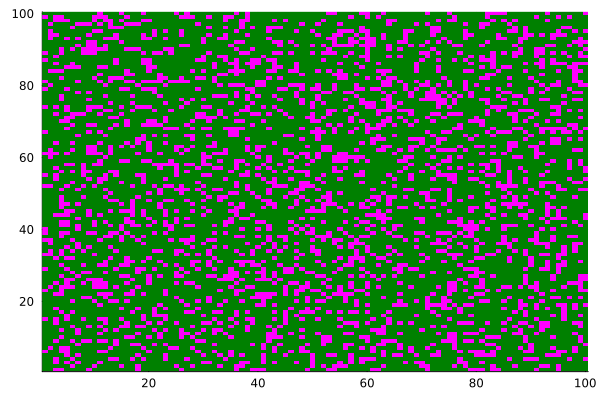

In [5]:
heatmap(lattice_n, colorbar=false, color=[:green, :magenta], clims=(0,1))

### La energía del sistema

La energía de un sistema en el modelo de Ising está dada por el **hamiltoniano**.
$$\mathcal H(\sigma) = -\sum_{\langle i, j\rangle} J_{ij}\sigma_i\sigma_j- \mu\sum_{i=1}^N B_i\sigma_i$$
Donde la notación $\langle i, j\rangle$ indica que la primera suma se realiza únicamente sobre los pares de spins vecinos. $J_{ij}$ representa un factor de acoplamiento entre los spins $i$ y $j$, $B_i$ representa la magnitud del campo magnético externo, y $\mu$ es el momento magnético.
A continuación consideraremos que $J_{ij}$ es constante, es decir, no depende del par $i,j$, y que no hay campo externo $B$. Además, como el hamiltoniano representa la energía del sistema escribiremos $E=\mathcal H$.

In [7]:
function get_energy(lattice, J=1)
    N, M = size(lattice)
    energy = 0.0

    for i in 1:N
        for j in 1:M 
            neighbors = 0

            #vecino de arriba
            if i > 1
                neighbors += lattice[i-1, j]
            elseif i == 1
                neighbors += lattice[N, j]
            end
            #vecino de abajo
            if i < N
                neighbors += lattice[i+1, j]
            elseif i == N
                neighbors += lattice[1, j]
            end
            #vecino de la izquierda
            if j > 1
                neighbors += lattice[i, j-1]
            elseif j == 1
                neighbors += lattice[i, M]
            end 
            #vecino de la derecha
            if j < M 
                neighbors += lattice[i, j+1]
            elseif j == M
                neighbors += lattice[i, 1]
            end

            energy -= J * lattice[i, j] * neighbors
        end
    end

    return energy / 2.0
end

print(get_energy(lattice_n, 1))

-4924.0

### Algoritmo de Metropolis para el modelo de Ising

1. Elegir un spin $\sigma_i$ al azar en el array.
2. Calcular el cambio en la energía $\Delta E$ que resultaría de dar vuelta ese spin $\sigma_i$.
3. Si $\Delta E< 0$, cambiamos el estado del spin $i$. Si $\Delta E >0$ cambiamos el estado del spin $i$ con una probabildad de $e^{-\Delta E/kt}$
4. Volver al paso 1.

Si representamos un estado completo de una malla por un vector $\sigma=(\sigma_1, \sigma_2,\dots, \sigma_N)$ con $\sigma_i\in\{-1,1\}$. La probabilidad de encontrar la lattice en un estado $\sigma$ es
$$p(\sigma) = \frac{1}{Z} e^{-E(\sigma)/kT}$$
Se quiere satisfacer una condición de equilibrio dada por
$$p(\sigma) P(\sigma\to\tau) = p(\tau) P(\tau\to\sigma)$$
Luego se satisface
$$\frac{P(\sigma\to \tau)}{P(\tau\to\sigma)}=\frac{p(\tau)}{p(\sigma)}=e^{-\Delta E/kT}$$
Donde $\Delta E = E(\tau)-E(\sigma)$. El algoritmo elige aceptar un cambio en el spin $i$ con probabilidad
$$P(\sigma\to\tau)=\min\{1, e^{-\Delta E/kT}\}$$

In [6]:
function metropolis(spin_arr, times, T, energy, J=1, K=1)
    spin_arr = copy(spin_arr)
    net_spins = zeros(times)
    net_energy = zeros(times)
    N, M = size(spin_arr)
    beta = 1/(K*T)
    snapshots = []

    pasos_snapshot = Set([
        1, 
        1 + div(times, 6), 
        1 + div(2*times, 6), 
        1 + div(3*times, 6), 
        1+ div(4*times, 6),
        times
    ])

    current_net_spin = sum(spin_arr)

    for t in 1:times
        # Elegimos un punto random en el array
        x = rand(1:N)
        y = rand(1:M)
        spin_i = spin_arr[x, y]
        spin_f = -1*spin_i

        E_i = 0
        E_f = 0

        #aplicamos los cambios en la energía
        if x > 1
            E_i += -J * spin_i * spin_arr[x-1, y]
            E_f += -J * spin_f * spin_arr[x-1, y]
        elseif x == 1
            E_i += -J * spin_i * spin_arr[N, y]
            E_f += -J * spin_f * spin_arr[N, y]
        end
        if x < N
            E_i += -J * spin_i * spin_arr[x+1, y]
            E_f += -J * spin_f * spin_arr[x+1, y]
        elseif x == N
            E_i += -J * spin_i * spin_arr[1, y]
            E_f += -J * spin_f * spin_arr[1, y]
        end
        if y > 1
            E_i += -J * spin_i * spin_arr[x, y-1]
            E_f += -J * spin_f * spin_arr[x, y-1]
        elseif y == 1
            E_i += -J * spin_i * spin_arr[x, M]
            E_f += -J * spin_f * spin_arr[x, M]
        end
        if y < M
            E_i += -J * spin_i * spin_arr[x, y+1]
            E_f += -J * spin_f * spin_arr[x, y+1]
        elseif y == M
            E_i += -J * spin_i * spin_arr[x, 1]
            E_f += -J * spin_f * spin_arr[x, 1]
        end

        dE = E_f - E_i

        #decidimos si volteamos el spin
        if (dE > 0) && (rand() < exp(-beta*dE))
            spin_arr[x, y] = spin_f
            energy += dE
            current_net_spin += 2 * spin_f
        elseif (dE <= 0)
            spin_arr[x, y] = spin_f
            energy += dE
            current_net_spin += 2 * spin_f
        end
        
        #net_spins[t] = sum(spin_arr)
        net_spins[t] = current_net_spin
        net_energy[t] = energy 

        if t in pasos_snapshot
            push!(snapshots, copy(spin_arr))
        end
    end
    return snapshots, net_spins, net_energy
end

metropolis (generic function with 3 methods)

### Complejidad

En general se suele considerar que una _iteración_ del algoritmo es cuando todos los puntos de la grilla han tenido la oportunidad de voltearse. Esto es que una iteración sería más o menos hacer que el `for` en el algoritmo se repita `times = N*M` veces donde $N\times M$ es el tamaño de la grilla. Luego si $m$ es el número de iteraciones (el número de veces que queremos que cada punto en la grilla tenga la oportunidad de cambiar) entonces la complejidad del algoritmo como está es
$$\mathcal O((N\times M)\cdot m)$$

### Experimentos

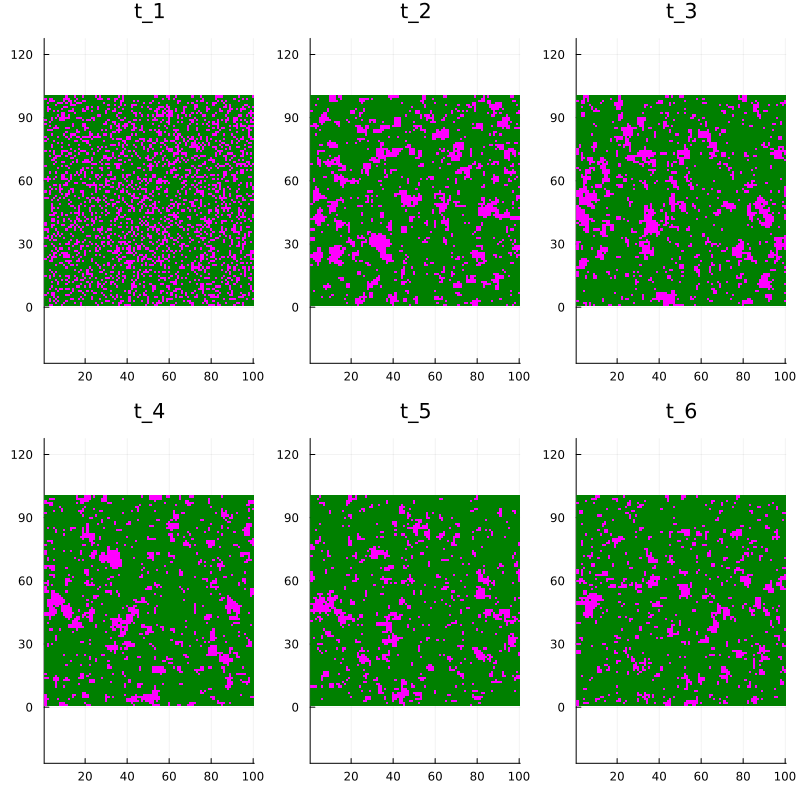

In [29]:
iteraciones = 50

snapshots, net_spins, net_energy = metropolis(lattice_n, N*N*iteraciones, 2.27, get_energy(lattice_n));

# Generar un heatmap para cada uno de los 4 snapshots
p1 = heatmap(snapshots[1], title="t_1",   color=[:green, :magenta], colorbar=false, aspect_ratio=:equal)
p2 = heatmap(snapshots[2], title="t_2", color=[:green, :magenta], colorbar=false, aspect_ratio=:equal)
p3 = heatmap(snapshots[3], title="t_3",  color=[:green, :magenta], colorbar=false, aspect_ratio=:equal)
p4 = heatmap(snapshots[4], title="t_4",  color=[:green, :magenta], colorbar=false, aspect_ratio=:equal)
p5 = heatmap(snapshots[5], title="t_5",  color=[:green, :magenta], colorbar=false, aspect_ratio=:equal)
p6 = heatmap(snapshots[6], title="t_6",  color=[:green, :magenta], colorbar=false, aspect_ratio=:equal)

plot(p1, p2, p3, p4, p5, p6, layout=(2, 3), size=(800, 800))

Si tenemos $N$ celdas en la grilla la magnetización promedio es
$$\mathcal M=\frac{1}{N}\sum_{i=1}^N\sigma_i$$

En este caso, como trabajamos en dos dimensiones sería mejor escribir

$$\mathcal M=\frac{1}{N\cdot M}\sum_{i=1}^N\sum_{j=1}^M\sigma_{ij}$$

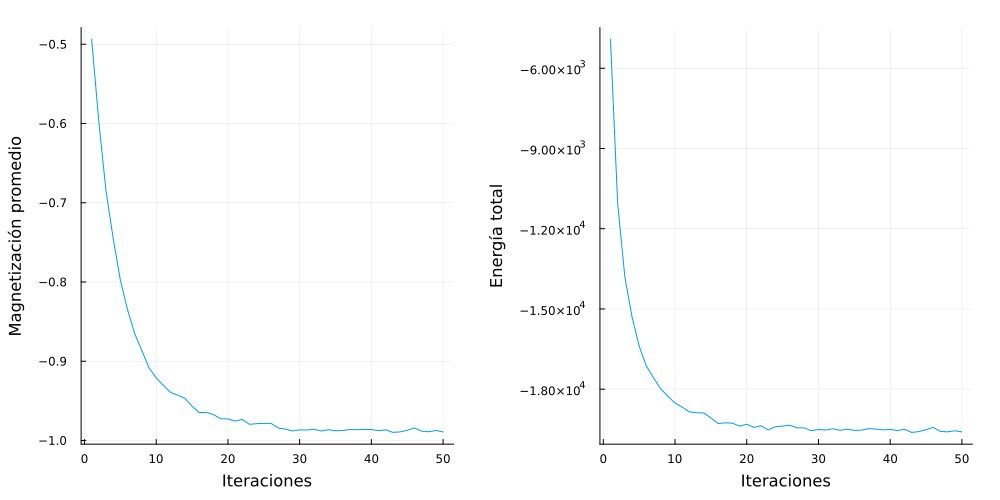

In [27]:
using Plots.PlotMeasures

#p_1 = plot(net_spins ./ N^2, xlabel="timesteps", ylabel="Magnetización promedio") #Esta es la magnetización promedio
#p_2 = plot(net_energy, xlabel="timesteps", ylabel="Energía total")

#plot(p_1, p_2, layout=(1, 2), size=(1000, 500), margin=5mm)

net_spins_sub  = (net_spins ./ N^2)[1:(N^2):end]
net_energy_sub = net_energy[1:(N^2):end]


p_1 = plot(net_spins_sub,  xlabel="Iteraciones", ylabel="Magnetización promedio", legend=false)
p_2 = plot(net_energy_sub, xlabel="Iteraciones", ylabel="Energía total", legend=false)

plot(p_1, p_2, layout=(1, 2), size=(1000, 500), margin=5mm)

In [23]:
function metropolis_f(spin_arr, times, T, energy, J=1, K=1)
    spin_arr = copy(spin_arr)
    net_spins = zeros(times)
    N, M = size(spin_arr)
    beta = 1/(K*T)
    current_net_spin = sum(spin_arr)

    for t in 1:times
        x = rand(1:N)
        y = rand(1:M)
        spin_i = spin_arr[x, y]
        spin_f = -1*spin_i
        E_i = 0
        E_f = 0

        if x > 1
            E_i += -J * spin_i * spin_arr[x-1, y]
            E_f += -J * spin_f * spin_arr[x-1, y]
        elseif x == 1
            E_i += -J * spin_i * spin_arr[N, y]
            E_f += -J * spin_f * spin_arr[N, y]
        end
        if x < N
            E_i += -J * spin_i * spin_arr[x+1, y]
            E_f += -J * spin_f * spin_arr[x+1, y]
        elseif x == N
            E_i += -J * spin_i * spin_arr[1, y]
            E_f += -J * spin_f * spin_arr[1, y]
        end
        if y > 1
            E_i += -J * spin_i * spin_arr[x, y-1]
            E_f += -J * spin_f * spin_arr[x, y-1]
        elseif y == 1
            E_i += -J * spin_i * spin_arr[x, M]
            E_f += -J * spin_f * spin_arr[x, M]
        end
        if y < M
            E_i += -J * spin_i * spin_arr[x, y+1]
            E_f += -J * spin_f * spin_arr[x, y+1]
        elseif y == M
            E_i += -J * spin_i * spin_arr[x, 1]
            E_f += -J * spin_f * spin_arr[x, 1]
        end

        dE = E_f - E_i
        if (dE > 0) && (rand() < exp(-beta*dE))
            spin_arr[x, y] = spin_f
            current_net_spin += 2 * spin_f
        elseif (dE <= 0)
            spin_arr[x, y] = spin_f
            current_net_spin += 2 * spin_f
        end
        
        net_spins[t] = current_net_spin
    end
    return net_spins
end

metropolis_f (generic function with 3 methods)

In [52]:
using Statistics
using StatsBase

function get_magnetization_sim(lattice_unif, lattice_rand, Ts, iter, sims, crit_temp)
    N, M = size(lattice_unif)
    num_Ts = length(Ts)
    mag_means = zeros(num_Ts)
    mag_stds  = zeros(num_Ts)
    mag_skew  = zeros(num_Ts)
    mag_kurt  = zeros(num_Ts)

    n_spins = N * M

    for (i, T) in enumerate(Ts) # Recorremos cada temperatura
        ens_means = zeros(sims)
        ens_vars  = zeros(sims)
        ens_skew  = zeros(sims)
        ens_kurt  = zeros(sims)

        for s in 1:sims # para cada temperatura repetimos sims veces

            # Elegimos la lattice dependiendo de la temperatura
            current_lattice = (T < crit_temp) ? copy(lattice_unif) : copy(lattice_rand)

            current_energy  = get_energy(current_lattice)
            spins = metropolis_f(current_lattice, n_spins * iter, T, current_energy)
            
            # Tomamos 1 muestra por cada paso Monte Carlo (cada N*M intentos)
            mag_time_series = spins[n_spins:n_spins:end] ./ n_spins
            
            # Descartamos las primeras 1000 iteraciones
            stationary_series = mag_time_series[(1000 + 1):end]

            # Si T < Tc y la magnetización promedio cayó en -1, invertimos el signo
            #if T < crit_temp && mean(stationary_series) < 0
            #    stationary_series = -stationary_series
            #end

            # obtenemos las métricas para esta simulación
            ens_means[s] = mean(stationary_series)
            ens_vars[s]  = var(stationary_series)
            ens_skew[s]  = skewness(stationary_series)
            ens_kurt[s]  = kurtosis(stationary_series)
        end

        # Sacamos el promedio de las métricas para esta temperatura sobre todas las simulaciones
        mag_means[i] = mean(ens_means)
        mag_stds[i]  = mean(ens_vars)
        mag_skew[i]  = mean(ens_skew)
        mag_kurt[i]  = mean(ens_kurt)
    end

    return mag_means, mag_stds, mag_skew, mag_kurt
end

get_magnetization_sim (generic function with 2 methods)

In [61]:
N = 100
init_random = rand(N, N)

lattice_unif = ones(Int, N, N)

lattice_rand = zeros(Int, N, N)
lattice_rand[init_random .>=0.5] .= 1
lattice_rand[init_random .< 0.5] .= -1

Ts = range(1.42, 3.12, step=0.05)
mag_means, mag_stds, mag_skew, mag_kurt = get_magnetization_sim(lattice_unif, lattice_rand, Ts, 4000, 500, 2.27)

([0.9905447253333333, 0.9881489902666668, 0.9853015386666668, 0.9819284830666667, 0.9779466412000001, 0.9732666155999999, 0.9677669549333334, 0.9612911587999999, 0.9536355405333332, 0.9445883126666668  …  -8.259426666666664e-5, 6.033720000000006e-5, -0.0004766514666666668, -3.40928e-5, 0.00013440306666666663, 7.815840000000002e-5, 1.4835333333333342e-5, -0.00035510773333333336, 6.600560000000002e-5, -0.0001261118666666667], [2.621946389045233e-6, 3.452621764828249e-6, 4.5113013078137065e-6, 5.89321203651885e-6, 7.673587751481619e-6, 1.000191640821609e-5, 1.3099839918017115e-5, 1.7231016111797224e-5, 2.295679679212185e-5, 3.0962284512535296e-5  …  0.002629557674284414, 0.0021895779515292923, 0.0019172548319882628, 0.0016782226347074622, 0.0014865510144931422, 0.0013329007818667022, 0.001207634011012711, 0.001105229382604477, 0.0010240560414736114, 0.0009420699573618674], [-0.24029445774637298, -0.23394179434088744, -0.22729404937133824, -0.22479927336526442, -0.22320950483255397, -0.223

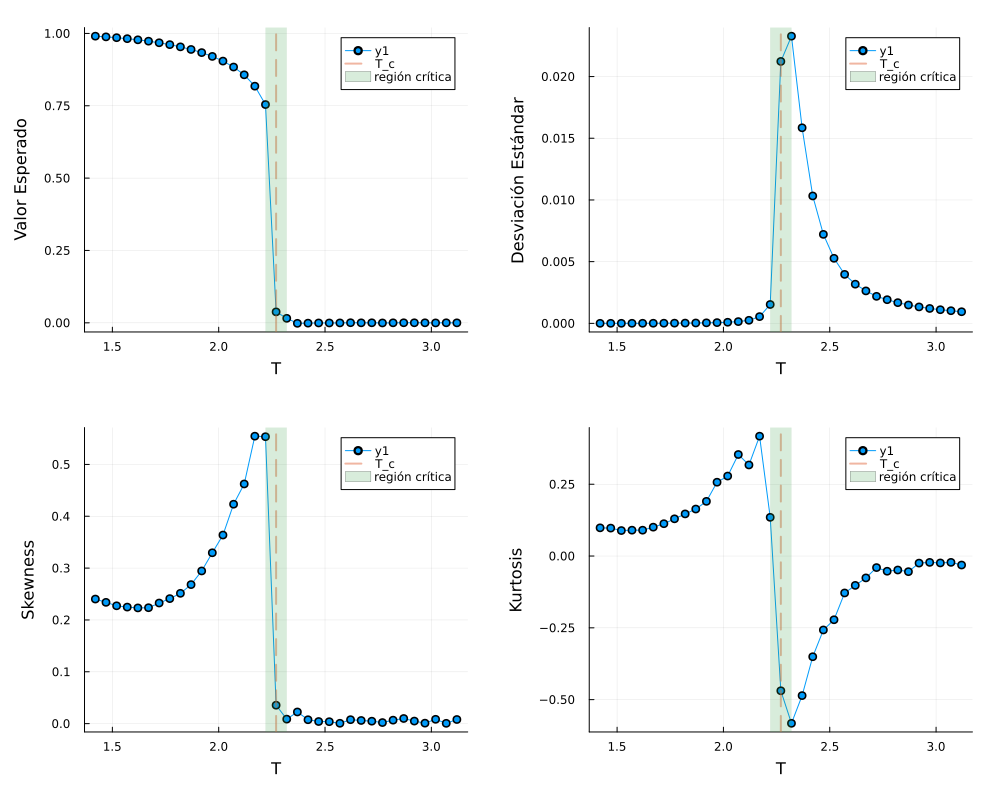

In [64]:
using Plots.PlotMeasures

p1 = plot(Ts, mag_means, xlabel="T", ylabel="Valor Esperado", marker=:circle)
vline!([2.27], label="T_c", linewidth=2, linestyle=:dash, opacity=0.5)
vspan!([2.22, 2.32], opacity=0.2, label="región crítica")
p2 = plot(Ts, mag_stds, xlabel="T", ylabel="Desviación Estándar", marker=:circle)
vline!([2.27], label="T_c", linewidth=2, linestyle=:dash, opacity=0.5)
vspan!([2.22, 2.32], opacity=0.2, label="región crítica")
p3 = plot(Ts, abs.(mag_skew), xlabel="T", ylabel="Skewness", marker=:circle)
vline!([2.27], label="T_c", linewidth=2, linestyle=:dash, opacity=0.5)
vspan!([2.22, 2.32], opacity=0.2, label="región crítica")
p4 = plot(Ts, mag_kurt, xlabel="T", ylabel="Kurtosis", marker=:circle)
vline!([2.27], label="T_c", linewidth=2, linestyle=:dash, opacity=0.5)
vspan!([2.22, 2.32], opacity=0.2, label="región crítica")

plot(p1, p2, p3, p4, layout=(2, 2), size=(1000, 800), margin=5mm)

## El algoritmo general

La idea del algoritmo de Metropolis-Hastings en general es, dada una distribución de probabilidad con densidad $p(x)$ encontrar una muestra de esta distribución incluso sin conocer la constante de normalización.

A veces no conocemos exactamente $p(x)$, la densidad de probabilidad, sino simplemente $g(x)$, que es proporcional a $p$ ($p(x)\propto g(x)$), donde para el caso continuo
$$\int_{-\infty}^\infty g(x) dx = Z\neq 1$$
o para el caso discreto
$$\sum_{i\in I}g(x_i)= Z\neq 1$$
es decir, la distribución no está normalizada. Para normalizar la distribución basta dividir por $Z$ sin embargo, no siempre podemos computar la integral fácilmente.

La idea es definir una **cadena de Markov** tal que converja a una distribución estacionaria que es justamente $p$. Es decir, esta cadena genera una secuencia $(x_1\dots, x_n)$ tal que $x_n\sim p(x)$ cuando $n\to\infty$. Hay muchas maneras de definir esta cadena, el algoritmo es una de ellas. 

Se considera una distribución propuesta que conozcamos $q$

El algoritmo es como sigue:
1. Se escoge un valor inicial $x_0$
2. Se escoge un _candidato_ $x^*\sim q(x^*\mid x_{i-1})$ 
3. Definimos la **probabilidad de aceptación** de ese candidato como $$A(x_n\to x^*)=\min\left(1, \frac{p(x^*)}{p(x_{i-1})}\frac{q(x_{i-1}\mid x^*)}{q(x^*\mid x_{i-1})}\right)$$ y aceptamos al candidato con esa probabilidad.
4. Hacemos $i\leftarrow i+1$ y volvemos al paso 2 hasta repetir $m$ veces.

Es importante notar que en la probabilidad de aceptación 
$$A(x_n\to x^*)=\min\left(1, \frac{p(x^*)}{p(x_{i-1})}\frac{q(x_{i-1}\mid x^*)}{q(x^*\mid x_{i-1})}\right)$$
el término $\frac{p(x^*)}{p(x_{i-1})}$ cancela la constante de normalización, por lo que lo podemos computar en principio. Si elegimos una distribución simétrica, entonces $q(x^*\mid x_{i-1})=q(x_{i-1}\mid x^*)$ y 
$$A(x_n\to x^*)=\min\left(1, \frac{p(x^*)}{p(x_{i-1})}\right)$$
Pero se podría elegir una distribución no simétrica perfectamente, de hecho generalizar para distribuciones no simétricas fue el trabajo de Hastings, por lo que al algoritmo simétrico se le suele llamar simplemente algoritmo de Metropolis.

En el caso del algoritmo que implementamos se escogió
$$q(x^*\mid x_{i-1})=\begin{cases} \frac{1}{N\cdot M}, &\text{si $x^*$ difiere de $x_{i-1}$ en exactamente un spin}\\ 0,&\text{en otro caso}\end{cases}$$
de forma que $q(x^*\mid x_{i-1})=q(x_{i-1}\mid x^*)$.

Además en el modelo de Ising la distribución de probabilidad es discreta, por eso la constante no se calcula con una integral, sino con una suma, la **función de partición**
$$Z=\sum_{\sigma\in X}e^{-E(\sigma)/kT}$$

Donde $X$ es el espacio de posibles configuraciones en un sistema de $M\cdot N$ spins y cada $\mu\in X$ es un vector de spins representando una configuración particular.


### Preguntas

- ¿Qué podría significar un sistema con un $J_{ij}$ no constante?
- ¿Cómo cambiaría con un campo externo?
- ¿Existen elecciones de la distribución $q$ para el algoritmo más eficientes? (Sí)

### Further Reading / Watching

- The Ising Model in Python - https://youtu.be/K--1hlv9yv0?si=Sc0gsNkEQ_I92Ly8
- Understanding Metropolis-Hastings algorithm - https://youtu.be/0lpT-yveuIA?si=mN78ksv4zhpG3E1g
- Kalos, Whitlock - Monte Carlo Methods
- Navarro, Danielle. 2023. “The Metropolis-Hastings Algorithm.” April 12, 2023. https://blog.djnavarro.net/posts/2023-04-12_metropolis-hastings/. 
- Contact Process Ising Model - https://github.com/jekeymer/Contact-Process-Ising-Model
